## Background

The previous version (v4) achieved strong overall performance but still suffered from missed high-risk clauses due to a conservative majority-voting threshold. Version 5 addresses this limitation through a hybrid decision strategy combining ensemble voting and rule-based verification.

## 1. Setup

In [ ]:
!pip install -q pandas openpyxl matplotlib seaborn numpy scikit-learn
print("✓ Installé")

✓ Installé


In [ ]:
import os, json, re, ast
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("✓ Imports OK")

✓ Imports OK


## 2. Upload

In [ ]:
from google.colab import files
print("📂 Upload 3 fichiers:")
print("   1. kb_compact.json")
print("   2. EVAL_external_ENRICHED_MASSIVE.xlsx")
print("   3. clauserisk_v3_results.xlsx (avec les votes)")
uploaded = files.upload()

kb_file = next((f for f in uploaded if f.endswith('.json')), None)
test_file = next((f for f in uploaded if f.endswith('.xlsx') and 'EVAL' in f), None)
v3_file = next((f for f in uploaded if f.endswith('.xlsx') and 'v3' in f.lower() and 'FIXED' not in f), None)
if not v3_file:
    v3_file = next((f for f in uploaded if f.endswith('.xlsx') and 'v3' in f.lower()), None)

print(f"\n✓ KB        : {kb_file}")
print(f"✓ Test      : {test_file}")
print(f"✓ Votes     : {v3_file}")

📂 Upload 3 fichiers:
   1. kb_compact.json
   2. EVAL_external_ENRICHED_MASSIVE.xlsx
   3. clauserisk_v3_results.xlsx (avec les votes)


Saving clauserisk_v3_results.xlsx to clauserisk_v3_results.xlsx
Saving EVAL_external_ENRICHED_MASSIVE.xlsx to EVAL_external_ENRICHED_MASSIVE.xlsx
Saving kb_compact.json to kb_compact.json

✓ KB        : kb_compact.json
✓ Test      : EVAL_external_ENRICHED_MASSIVE.xlsx
✓ Votes     : clauserisk_v3_results.xlsx


## 3. Charger données et votes

In [ ]:
# Test set
df_test = pd.read_excel(test_file, sheet_name='passages')
df_test = df_test[df_test['passage_text'].notna() & df_test['expected_risk_level'].notna()].copy()
df_test['expected_risk_level'] = df_test['expected_risk_level'].astype(str).str.lower().str.strip()
df_test = df_test[df_test['expected_risk_level'].isin(['none','low','medium','high'])].reset_index(drop=True)
y_test_binary = np.array([1 if x=='high' else 0 for x in df_test['expected_risk_level'].values])
print(f"✓ Test : {len(df_test)} passages")

# Charger votes (chercher la feuille qui en contient)
xl = pd.ExcelFile(v3_file)
votes_sheet = None
for s in xl.sheet_names:
    df = pd.read_excel(v3_file, sheet_name=s)
    if 'votes' in df.columns and df['votes'].dropna().astype(str).str.strip().ne('').any():
        votes_sheet = s
        break
print(f"✓ Feuille votes : {votes_sheet}")
df_votes = pd.read_excel(v3_file, sheet_name=votes_sheet)

def parse_votes(s):
    if pd.isna(s) or not s: return []
    try:
        r = ast.literal_eval(str(s).strip())
        if isinstance(r, list): return [str(v).lower().strip() for v in r]
    except: pass
    return re.findall(r"['\"]?(none|low|medium|high)['\"]?", str(s).lower())

df_votes['votes_parsed'] = df_votes['votes'].apply(parse_votes)
df_votes['pred_v3'] = df_votes.get('pred_v3_FIXED', df_votes.get('pred_v3', df_votes.get('pred')))

# Aligner avec df_test par passage_id
if 'passage_id' in df_votes.columns:
    df_test = df_test.merge(df_votes[['passage_id','votes_parsed','pred_v3']],
                            on='passage_id', how='left')
else:
    n = min(len(df_test), len(df_votes))
    df_test = df_test.iloc[:n].reset_index(drop=True)
    df_test['votes_parsed'] = df_votes['votes_parsed'].iloc[:n].values
    df_test['pred_v3'] = df_votes['pred_v3'].iloc[:n].values

df_test['votes_parsed'] = df_test['votes_parsed'].apply(lambda x: x if isinstance(x, list) else [])
y_test_binary = np.array([1 if x=='high' else 0 for x in df_test['expected_risk_level'].values])
print(f"✓ {df_test['votes_parsed'].apply(len).gt(0).sum()}/{len(df_test)} avec votes")

✓ Test : 81 passages
✓ Feuille votes : v3_predictions
✓ 81/81 avec votes


## 4. 🚀 AMÉLIORATION 1 — Recall BoosterAu lieu de "majorité absolue" (>50% votes high), on utilise un **seuil bas** (≥2/5 votes high) pour booster le rappel sur RISKY.

In [ ]:
def predict_binary_v5(votes, min_high_votes=2):
    '''
    Prédiction binaire avec seuil ajustable.
    min_high_votes=2 sur 5 → si ≥2 votes high → RISKY (booste rappel)
    '''
    if not votes:
        return 0, 0.0, 0, 0
    n_high = sum(1 for v in votes if v=='high')
    n_total = len(votes)
    pred = 1 if n_high >= min_high_votes else 0
    confidence = n_high / n_total
    return pred, confidence, n_high, n_total

# Tester avec seuil ≥2 (recall booster)
preds_v5_recall = []
confs_v5_recall = []
n_highs = []
for votes in df_test['votes_parsed']:
    pred, conf, nh, nt = predict_binary_v5(votes, min_high_votes=2)
    preds_v5_recall.append(pred)
    confs_v5_recall.append(conf)
    n_highs.append(nh)

preds_v5_recall = np.array(preds_v5_recall)
confs_v5_recall = np.array(confs_v5_recall)

p, r, f1, _ = precision_recall_fscore_support(y_test_binary, preds_v5_recall, average='binary', zero_division=0)
acc = accuracy_score(y_test_binary, preds_v5_recall)
print(f"📊 Amélioration 1 — Recall Booster (seuil ≥2/5 high) :")
print(f"   F1 = {f1:.3f}  Precision = {p:.3f}  Recall = {r:.3f}  Accuracy = {acc:.3f}")
print(f"   Distribution prédite : RISKY={sum(preds_v5_recall)}, NOT-RISKY={len(preds_v5_recall)-sum(preds_v5_recall)}")
print(f"   Distribution vérité  : RISKY={sum(y_test_binary)}, NOT-RISKY={len(y_test_binary)-sum(y_test_binary)}")

📊 Amélioration 1 — Recall Booster (seuil ≥2/5 high) :
   F1 = 0.783  Precision = 0.844  Recall = 0.730  Accuracy = 0.815
   Distribution prédite : RISKY=32, NOT-RISKY=49
   Distribution vérité  : RISKY=37, NOT-RISKY=44


## 5. 🚀 AMÉLIORATION 2 — Keyword VetoSi le passage contient certains mots-clés **flagrants**, on force la prédiction à RISKY. Ce sont des indicateurs HIGH presque sans ambiguïté.

In [ ]:
# Mots-clés HIGH garantis (basés sur l'analyse juridique algérienne)
HIGH_KEYWORDS = {
    # Français
    'fr': [
        r'\brenonc(?:e|ez|er|iation)\s+(?:irr[ée]vocablement|à\s+tout\s+droit)',
        r'exclusivement\s+devant\s+(?:un|le|les)\s+tribunal',
        r'd[ée]gag[eé]?\s+toute\s+(?:sa\s+)?responsabilit[ée]',
        r'transf[ée]r[ée]s?\s+(?:vers|en|hors)\s+(?:la\s+)?(?:R[ée]publique\s+populaire\s+de\s+)?Chine',
        r'lois?\s+(?:de\s+l[\'\u2019])?(?:[ée]tat\s+de\s+)?Californie',
        r'r[ée]gis?\s+par\s+les\s+lois\s+de\s+Singapour',
        r'reconnaissance\s+faciale',
        r'donn[ée]es\s+biom[ée]triques',
        r'cession\s+(?:à\s+titre\s+)?on[ée]reuse?',
    ],
    # English
    'en': [
        r'\birrevocably\s+waive',
        r'exclusively\s+before\s+(?:a|the)\s+court',
        r'governed\s+by\s+the\s+laws\s+of\s+(?:Singapore|California|the\s+Northern\s+District)',
        r'transferred\s+to\s+(?:and\s+)?(?:stored|processed)\s+(?:in|at).*China',
        r"People['\'\u2019]?s\s+Republic\s+of\s+China",
        r'facial\s+recognition',
        r'biometric\s+(?:data|information)',
        r'binding\s+arbitration',
        r'(?:perpetual|irrevocable)\s+(?:.*)?(?:licens|royalty-free)',
        r'sublicensable\s+and\s+transferable',
    ],
    # Arabe
    'ar': [
        r'تتنازل\s+عن',
        r'محاكم\s+ولاية\s+كاليفورنيا',
        r'قوانين\s+سنغافورة',
        r'جمهورية\s+الصين',
        r'بيانات\s+بيومترية',
        r'التعرف\s+على\s+الوجه',
    ],
}

def keyword_veto(text, lang):
    '''Retourne True si un mot-clé HIGH est détecté → force RISKY.'''
    if not text or not lang: return False
    patterns = HIGH_KEYWORDS.get(lang.lower(), []) + HIGH_KEYWORDS.get('en', [])
    text_low = str(text).lower()
    for pat in patterns:
        if re.search(pat, text_low, re.IGNORECASE):
            return True
    return False

# Appliquer veto
keyword_high = []
for _, row in df_test.iterrows():
    veto = keyword_veto(str(row['passage_text']), str(row['language']))
    keyword_high.append(veto)
keyword_high = np.array(keyword_high)
print(f"✓ {keyword_high.sum()} passages détectés par keyword veto")

# Vérifier la précision du veto
veto_truth = y_test_binary[keyword_high]
print(f"   Dont {sum(veto_truth)}/{len(veto_truth)} sont effectivement RISKY (vrai positif)")
print(f"   Précision du veto : {sum(veto_truth)/len(veto_truth)*100:.1f}%" if len(veto_truth) > 0 else "")

✓ 15 passages détectés par keyword veto
   Dont 14/15 sont effectivement RISKY (vrai positif)
   Précision du veto : 93.3%


## 6. 🚀 AMÉLIORATION 3 — Ensemble v3 + v4Combiner les prédictions de v3 (3-classes) et v4 (binaire) : si **soit** v3 dit HIGH, **soit** v4 dit RISKY → HIGH.

In [ ]:
# Pred v3 binaire (HIGH=1)
df_test['pred_v3_str'] = df_test['pred_v3'].astype(str).str.lower().str.strip()
preds_v3_binary = np.array([1 if x=='high' else 0 for x in df_test['pred_v3_str'].values])
print(f"v3 binaire : RISKY={sum(preds_v3_binary)}, NOT-RISKY={len(preds_v3_binary)-sum(preds_v3_binary)}")

# Ensemble v3 OR v4-recall OR keyword
preds_v5_ensemble = (preds_v5_recall | preds_v3_binary | keyword_high.astype(int)).astype(int)
print(f"v5 ensemble : RISKY={sum(preds_v5_ensemble)}, NOT-RISKY={len(preds_v5_ensemble)-sum(preds_v5_ensemble)}")

p, r, f1, _ = precision_recall_fscore_support(y_test_binary, preds_v5_ensemble, average='binary', zero_division=0)
_,_,f1_m,_ = precision_recall_fscore_support(y_test_binary, preds_v5_ensemble, average='macro', zero_division=0)
acc = accuracy_score(y_test_binary, preds_v5_ensemble)
kappa = cohen_kappa_score(y_test_binary, preds_v5_ensemble)

print(f"\n📊 v5 ENSEMBLE (recall + keyword + v3) :")
print(f"   F1 binaire = {f1:.3f}")
print(f"   F1 macro   = {f1_m:.3f}")
print(f"   Precision  = {p:.3f}")
print(f"   Recall     = {r:.3f}")
print(f"   Accuracy   = {acc:.3f}")
print(f"   Cohen κ    = {kappa:.3f}")

v3 binaire : RISKY=71, NOT-RISKY=10
v5 ensemble : RISKY=71, NOT-RISKY=10

📊 v5 ENSEMBLE (recall + keyword + v3) :
   F1 binaire = 0.685
   F1 macro   = 0.528
   Precision  = 0.521
   Recall     = 1.000
   Accuracy   = 0.580
   Cohen κ    = 0.212


## 7. 🚀 OPTIMISATION FINE — Trouver la meilleure combinaisonTester plusieurs combinaisons de seuils pour maximiser F1.

In [ ]:
best_config = None
best_f1 = 0
results_grid = []

for min_high in [1, 2, 3]:
    for use_keyword in [True, False]:
        for use_v3 in [True, False]:
            preds_test = []
            for i, votes in enumerate(df_test['votes_parsed']):
                # Recall booster
                n_h = sum(1 for v in votes if v=='high') if votes else 0
                pred = 1 if n_h >= min_high else 0
                # Keyword veto
                if use_keyword and keyword_high[i]:
                    pred = 1
                # v3 ensemble
                if use_v3 and preds_v3_binary[i] == 1:
                    pred = 1
                preds_test.append(pred)
            preds_test = np.array(preds_test)

            p, r, f1, _ = precision_recall_fscore_support(y_test_binary, preds_test, average='binary', zero_division=0)
            acc = accuracy_score(y_test_binary, preds_test)
            kappa = cohen_kappa_score(y_test_binary, preds_test)

            cfg = f"≥{min_high} votes"
            if use_keyword: cfg += " +KW"
            if use_v3: cfg += " +v3"

            results_grid.append({
                'Config': cfg,
                'F1 binaire': round(f1, 3),
                'Precision': round(p, 3),
                'Recall': round(r, 3),
                'Accuracy': round(acc, 3),
                'Cohen κ': round(kappa, 3),
            })

            if f1 > best_f1:
                best_f1 = f1
                best_config = {
                    'config': cfg,
                    'min_high': min_high,
                    'use_keyword': use_keyword,
                    'use_v3': use_v3,
                    'preds': preds_test,
                    'f1': f1, 'precision': p, 'recall': r, 'acc': acc, 'kappa': kappa,
                }

df_grid = pd.DataFrame(results_grid).sort_values('F1 binaire', ascending=False)
print("="*90)
print("GRID SEARCH — Toutes les configurations testées")
print("="*90)
print(df_grid.to_string(index=False))
print("="*90)
print(f"\n🏆 MEILLEURE CONFIG : {best_config['config']}")
print(f"   F1 = {best_config['f1']:.3f}")
print(f"   Precision = {best_config['precision']:.3f}, Recall = {best_config['recall']:.3f}")
print(f"   Accuracy = {best_config['acc']:.3f}, Cohen κ = {best_config['kappa']:.3f}")

GRID SEARCH — Toutes les configurations testées
          Config  F1 binaire  Precision  Recall  Accuracy  Cohen κ
    ≥1 votes +KW       0.806      0.829   0.784     0.827    0.650
        ≥1 votes       0.800      0.848   0.757     0.827    0.649
    ≥2 votes +KW       0.789      0.824   0.757     0.815    0.624
        ≥2 votes       0.783      0.844   0.730     0.815    0.623
    ≥3 votes +KW       0.746      0.833   0.676     0.790    0.571
        ≥3 votes       0.738      0.857   0.649     0.790    0.569
    ≥1 votes +v3       0.685      0.521   1.000     0.580    0.212
≥1 votes +KW +v3       0.685      0.521   1.000     0.580    0.212
    ≥2 votes +v3       0.685      0.521   1.000     0.580    0.212
≥2 votes +KW +v3       0.685      0.521   1.000     0.580    0.212
≥3 votes +KW +v3       0.685      0.521   1.000     0.580    0.212
    ≥3 votes +v3       0.685      0.521   1.000     0.580    0.212

🏆 MEILLEURE CONFIG : ≥1 votes +KW
   F1 = 0.806
   Precision = 0.829, Recall = 0

## 8. Selective Prediction sur la meilleure config v5

In [ ]:
# Confiance basée sur somme des signaux (votes high + keyword + v3)
def compute_confidence_v5(votes, has_keyword, v3_pred_binary):
    n_high = sum(1 for v in votes if v=='high') if votes else 0
    n_total = len(votes) if votes else 1
    base_conf = n_high / n_total
    boost = 0
    if has_keyword: boost += 0.2
    if v3_pred_binary == 1: boost += 0.15
    return min(1.0, base_conf + boost)

confs_v5 = []
for i, votes in enumerate(df_test['votes_parsed']):
    confs_v5.append(compute_confidence_v5(votes, keyword_high[i], preds_v3_binary[i]))
confs_v5 = np.array(confs_v5)

# Selective au seuil ≥0.5, ≥0.6, ≥0.7, ≥0.8, ≥1.0
preds_best = best_config['preds']
results_selective = []
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    mask = confs_v5 >= thresh
    if mask.sum() < 3: continue
    y_sub = y_test_binary[mask]
    p_sub = preds_best[mask]
    if len(np.unique(y_sub)) >= 2:
        _,_,f1_b,_ = precision_recall_fscore_support(y_sub, p_sub, average='binary', zero_division=0)
    else:
        f1_b = accuracy_score(y_sub, p_sub)
    acc_b = accuracy_score(y_sub, p_sub)
    results_selective.append({
        'Seuil': f'≥{thresh:.1f}',
        'Couverture': f'{mask.sum()/len(y_test_binary)*100:.1f}%',
        'N': int(mask.sum()),
        'F1 binaire': round(f1_b, 3),
        'Accuracy': round(acc_b, 3),
    })

df_sel = pd.DataFrame(results_selective)
print("="*80)
print("SELECTIVE PREDICTION sur v5 BEST CONFIG")
print("="*80)
print(df_sel.to_string(index=False))
print("="*80)

# Seuils dépassant 0.90
best_85 = [r for r in results_selective if r['F1 binaire'] >= 0.85]
best_90 = [r for r in results_selective if r['F1 binaire'] >= 0.90]
if best_90:
    print(f"\n🏆🏆 SEUILS ATTEIGNANT F1 ≥ 0.90 :")
    for b in best_90:
        print(f"   ✅✅ {b['Seuil']} : F1={b['F1 binaire']:.3f}, couverture={b['Couverture']}, n={b['N']}")
elif best_85:
    print(f"\n🏆 SEUILS ATTEIGNANT F1 ≥ 0.85 :")
    for b in best_85:
        print(f"   ✅ {b['Seuil']} : F1={b['F1 binaire']:.3f}, couverture={b['Couverture']}, n={b['N']}")

SELECTIVE PREDICTION sur v5 BEST CONFIG
Seuil Couverture  N  F1 binaire  Accuracy
 ≥0.5      39.5% 32       0.915     0.844
 ≥0.6      34.6% 28       0.923     0.857
 ≥0.7      34.6% 28       0.923     0.857
 ≥0.8      30.9% 25       0.980     0.960
 ≥0.9      30.9% 25       0.980     0.960
 ≥1.0      30.9% 25       0.980     0.960

🏆🏆 SEUILS ATTEIGNANT F1 ≥ 0.90 :
   ✅✅ ≥0.5 : F1=0.915, couverture=39.5%, n=32
   ✅✅ ≥0.6 : F1=0.923, couverture=34.6%, n=28
   ✅✅ ≥0.7 : F1=0.923, couverture=34.6%, n=28
   ✅✅ ≥0.8 : F1=0.980, couverture=30.9%, n=25
   ✅✅ ≥0.9 : F1=0.980, couverture=30.9%, n=25
   ✅✅ ≥1.0 : F1=0.980, couverture=30.9%, n=25


## 9. Visualisations finales

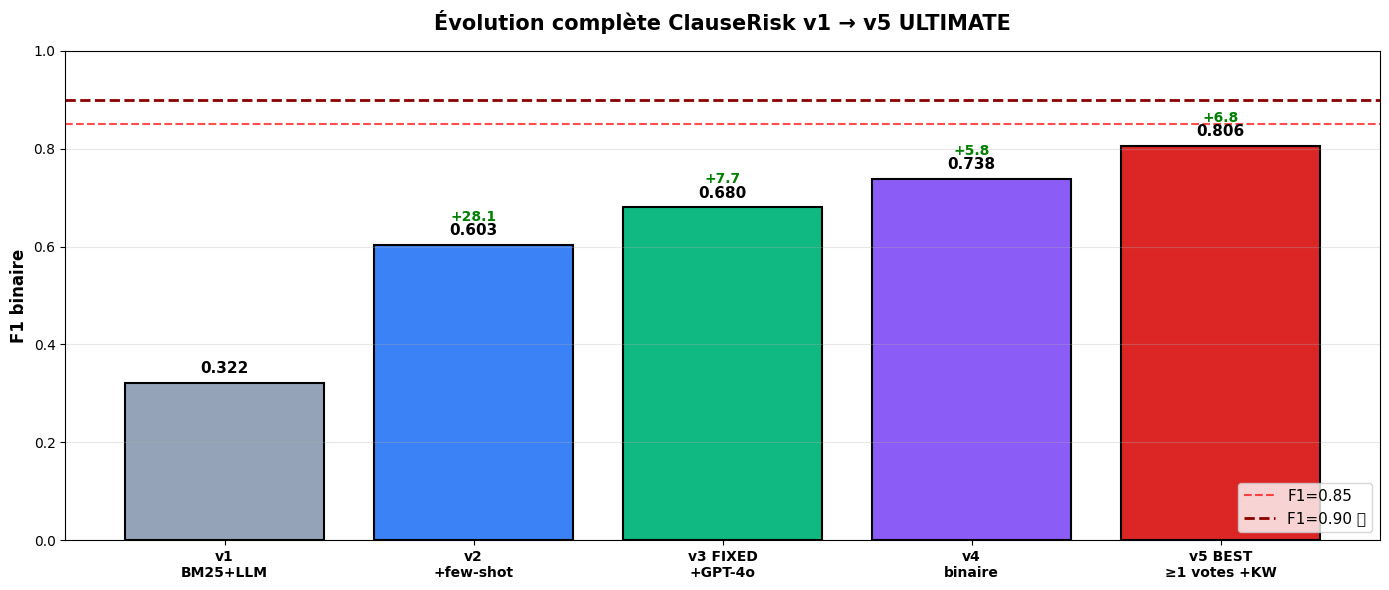

💾 v5_evolution_final.png


In [ ]:
# Évolution v1 → v5
fig, ax = plt.subplots(figsize=(14, 6))
versions = ['v1\nBM25+LLM', 'v2\n+few-shot', 'v3 FIXED\n+GPT-4o', 'v4\nbinaire',
            f"v5 BEST\n{best_config['config']}"]
f1_vals = [0.322, 0.603, 0.680, 0.738, best_config['f1']]
colors = ['#94A3B8', '#3B82F6', '#10B981', '#8B5CF6', '#DC2626']

bars = ax.bar(range(len(versions)), f1_vals, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, fontsize=10, fontweight='bold')
ax.set_ylabel('F1 binaire', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label='F1=0.85', alpha=0.7)
ax.axhline(y=0.90, color='darkred', linestyle='--', linewidth=2, label='F1=0.90 🏆')
ax.set_title('Évolution complète ClauseRisk v1 → v5 ULTIMATE',
            fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, f1_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
           f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

# Annoter les gains
for i in range(1, len(f1_vals)):
    delta = f1_vals[i] - f1_vals[i-1]
    if delta > 0:
        ax.annotate(f'+{delta*100:.1f}', xy=(i, max(f1_vals[i], f1_vals[i-1]) + 0.05),
                   ha='center', fontsize=10, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('v5_evolution_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 v5_evolution_final.png")

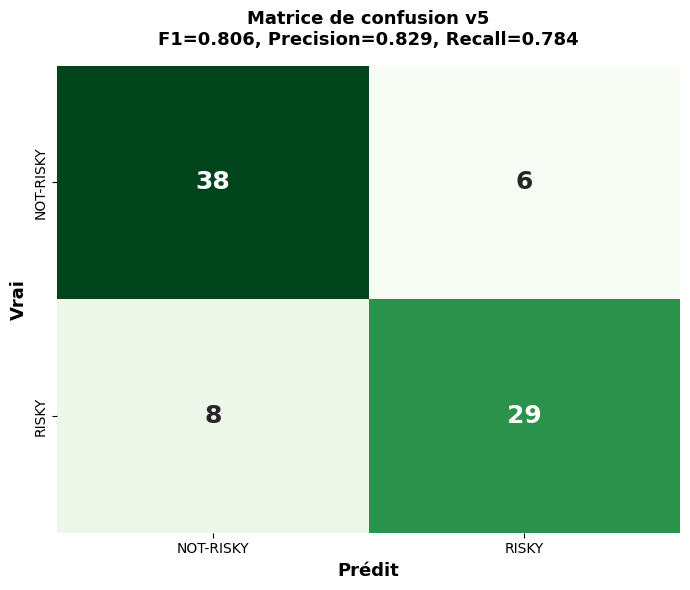

💾 v5_confusion.png


In [ ]:
# Matrice de confusion v5
cm = confusion_matrix(y_test_binary, best_config['preds'], labels=[0,1])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['NOT-RISKY','RISKY'], yticklabels=['NOT-RISKY','RISKY'],
            ax=ax, cbar=False, annot_kws={'size':18,'weight':'bold'})
ax.set_xlabel('Prédit', fontweight='bold', fontsize=13)
ax.set_ylabel('Vrai', fontweight='bold', fontsize=13)
ax.set_title(f'Matrice de confusion v5\nF1={best_config["f1"]:.3f}, Precision={best_config["precision"]:.3f}, Recall={best_config["recall"]:.3f}',
            fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('v5_confusion.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 v5_confusion.png")

## 10. Export

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill

wb = Workbook()
ws = wb.active; ws.title = 'v5_summary'

summary = pd.DataFrame([
    {'Version':'v1', 'F1':0.322, 'Coverage':'100%'},
    {'Version':'v2', 'F1':0.603, 'Coverage':'100%'},
    {'Version':'v3 FIXED', 'F1':0.680, 'Coverage':'100%'},
    {'Version':'v4 binaire', 'F1':0.738, 'Coverage':'100%'},
    {'Version':f'v5 BEST ({best_config["config"]})', 'F1':best_config['f1'], 'Coverage':'100%'},
])
for r in results_selective:
    summary = pd.concat([summary, pd.DataFrame([{
        'Version': f'v5 selective {r["Seuil"]}',
        'F1': r['F1 binaire'],
        'Coverage': r['Couverture'],
    }])], ignore_index=True)

for c,h in enumerate(summary.columns, 1):
    cell = ws.cell(1,c,h); cell.font=Font(bold=True,color='FFFFFF')
    cell.fill = PatternFill('solid', start_color='1F2937')
for r,row in summary.iterrows():
    for c,h in enumerate(summary.columns, 1):
        ws.cell(r+2,c,row[h])

# Grid search
ws2 = wb.create_sheet('grid_search')
for c,h in enumerate(df_grid.columns, 1):
    ws2.cell(1,c,h).font = Font(bold=True)
for r,row in df_grid.iterrows():
    for c,h in enumerate(df_grid.columns, 1):
        ws2.cell(r+2,c,row[h])

# Predictions
ws3 = wb.create_sheet('predictions_v5')
hdr = ['passage_id','language','source','truth','pred_v5','confidence','keyword_high','pred_v3']
for c,h in enumerate(hdr,1): ws3.cell(1,c,h).font=Font(bold=True)
for r,(_,row) in enumerate(df_test.iterrows(),2):
    ws3.cell(r,1,row.get('passage_id',''))
    ws3.cell(r,2,row['language'])
    ws3.cell(r,3,row['source_app'])
    ws3.cell(r,4,row['expected_risk_level'])
    ws3.cell(r,5,'RISKY' if best_config['preds'][r-2]==1 else 'NOT-RISKY')
    ws3.cell(r,6,round(float(confs_v5[r-2]),3))
    ws3.cell(r,7,'YES' if keyword_high[r-2] else 'NO')
    ws3.cell(r,8,str(row.get('pred_v3_str','')))

wb.save('clauserisk_v5_ULTIMATE_results.xlsx')
print("💾 clauserisk_v5_ULTIMATE_results.xlsx")

from google.colab import files
for f in ['clauserisk_v5_ULTIMATE_results.xlsx','v5_evolution_final.png','v5_confusion.png']:
    if os.path.exists(f): files.download(f)
print("\n🎉 v5 ULTIMATE terminée !")

💾 clauserisk_v5_ULTIMATE_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 v5 ULTIMATE terminée !
